In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd#FOr reading the sounding ONLY

#Define the constant
R_d = 287
R_v = 461.5
C_pd = 1004
L_v = 2.5 * 10 ** 6
g = 9.81
dry_lapse = 9.8 * 10**-3 #k m^-1


def skewT(temp, pres, skew=-20):
    """
    Skews the temperature axis for a SkewT plot.
    temp: temperature values (deg C)
    pres: pressure values (hPa)
    skew: amount of skew (default of -20)
    """
    return (temp) + skew * np.log(pres/1000.0)

def e_s(temp):
    return (6.112) * np.exp(17.67 * (temp - 273.145)/(temp - 29.65))
    #return (6.112) * np.exp(17.67 * (temp)/(temp + 243.5))#uses temp in C instead

def r_s(temp, pres):
    e_sat = e_s(temp)
    return 0.622 * e_sat / (pres - e_sat)

def moist_lapse(temp, pres):
    num = (1 + (L_v * r_s(temp, pres))/(R_d* temp))
    den = (1 + ((L_v ** 2) * r_s(temp, pres))/(C_pd * R_v * (temp ** 2)))

    frac = num / den
    return (g / C_pd) * frac

#Ok, i see what needs to happen here. 
# I need to numerically solve the moist lapse pde
def get_moist_lapse_rate(temp, pres_array):
    moist_adiabat = []

    temp = temp + 273.15#Convert to Kelvin
    moist_adiabat.append(temp)

    #Need to start at ground pressure and go up, so reverse list
    pres_array_rev = pres_array[::-1]

    for i in range(len(pres_array) - 1):
        #Get the moist lapse rate from the method provided
        current_lapse = moist_lapse(temp, pres_array_rev[i])

        
        #Need to calculate thickness of parcel for lapse rate and numerical integration: Use hypsometric equation!
        #Not using virtual temp, might add.
        p1 = pres_array_rev[i]
        p2 = pres_array_rev[i + 1]

        dz_moist = (R_d * temp) / g * np.log(p1 / p2)

        
        #Again I am really really dumb
        #This temp profile i am making *is* the moist adiabat.
        #Never let me do this ever again.
        #Calculate the new temp:
        temp = temp - current_lapse * dz_moist
        moist_adiabat.append(temp)

    return np.array(moist_adiabat) - 273.15#Convert back to C
 


In [ ]:
#Now, create arrays of pressure and temps
temp_array = np.arange(-90, 60, 10)
pres_array = np.arange(100, 1001, 1)

#Now skew the temperature here.
temp_skewed = []
for temp in temp_array:
    temp_skewed.append(skewT(temp, pres_array))
temp_skewed = np.asarray(temp_skewed)

#Make vertical moist adiabatic lapse rate
#Compared to what we derived in class, i think this needs to be in kelvin
temp_array_k = temp_array + 273.15

#Get pressure array in pascals
p = pres_array * 100



In [19]:
#Read in the Pauls Valley sounding
sounding = pd.read_csv("Pauls_Valley_Tor_05172025_21z_Norman.csv")

In [ ]:
#Get variables for Pauls Valley sounding
sounding_temp = sounding['temperature_C']
sounding_dew = sounding['dew point temperature_C']
sounding_pres = sounding['pressure_hPa']

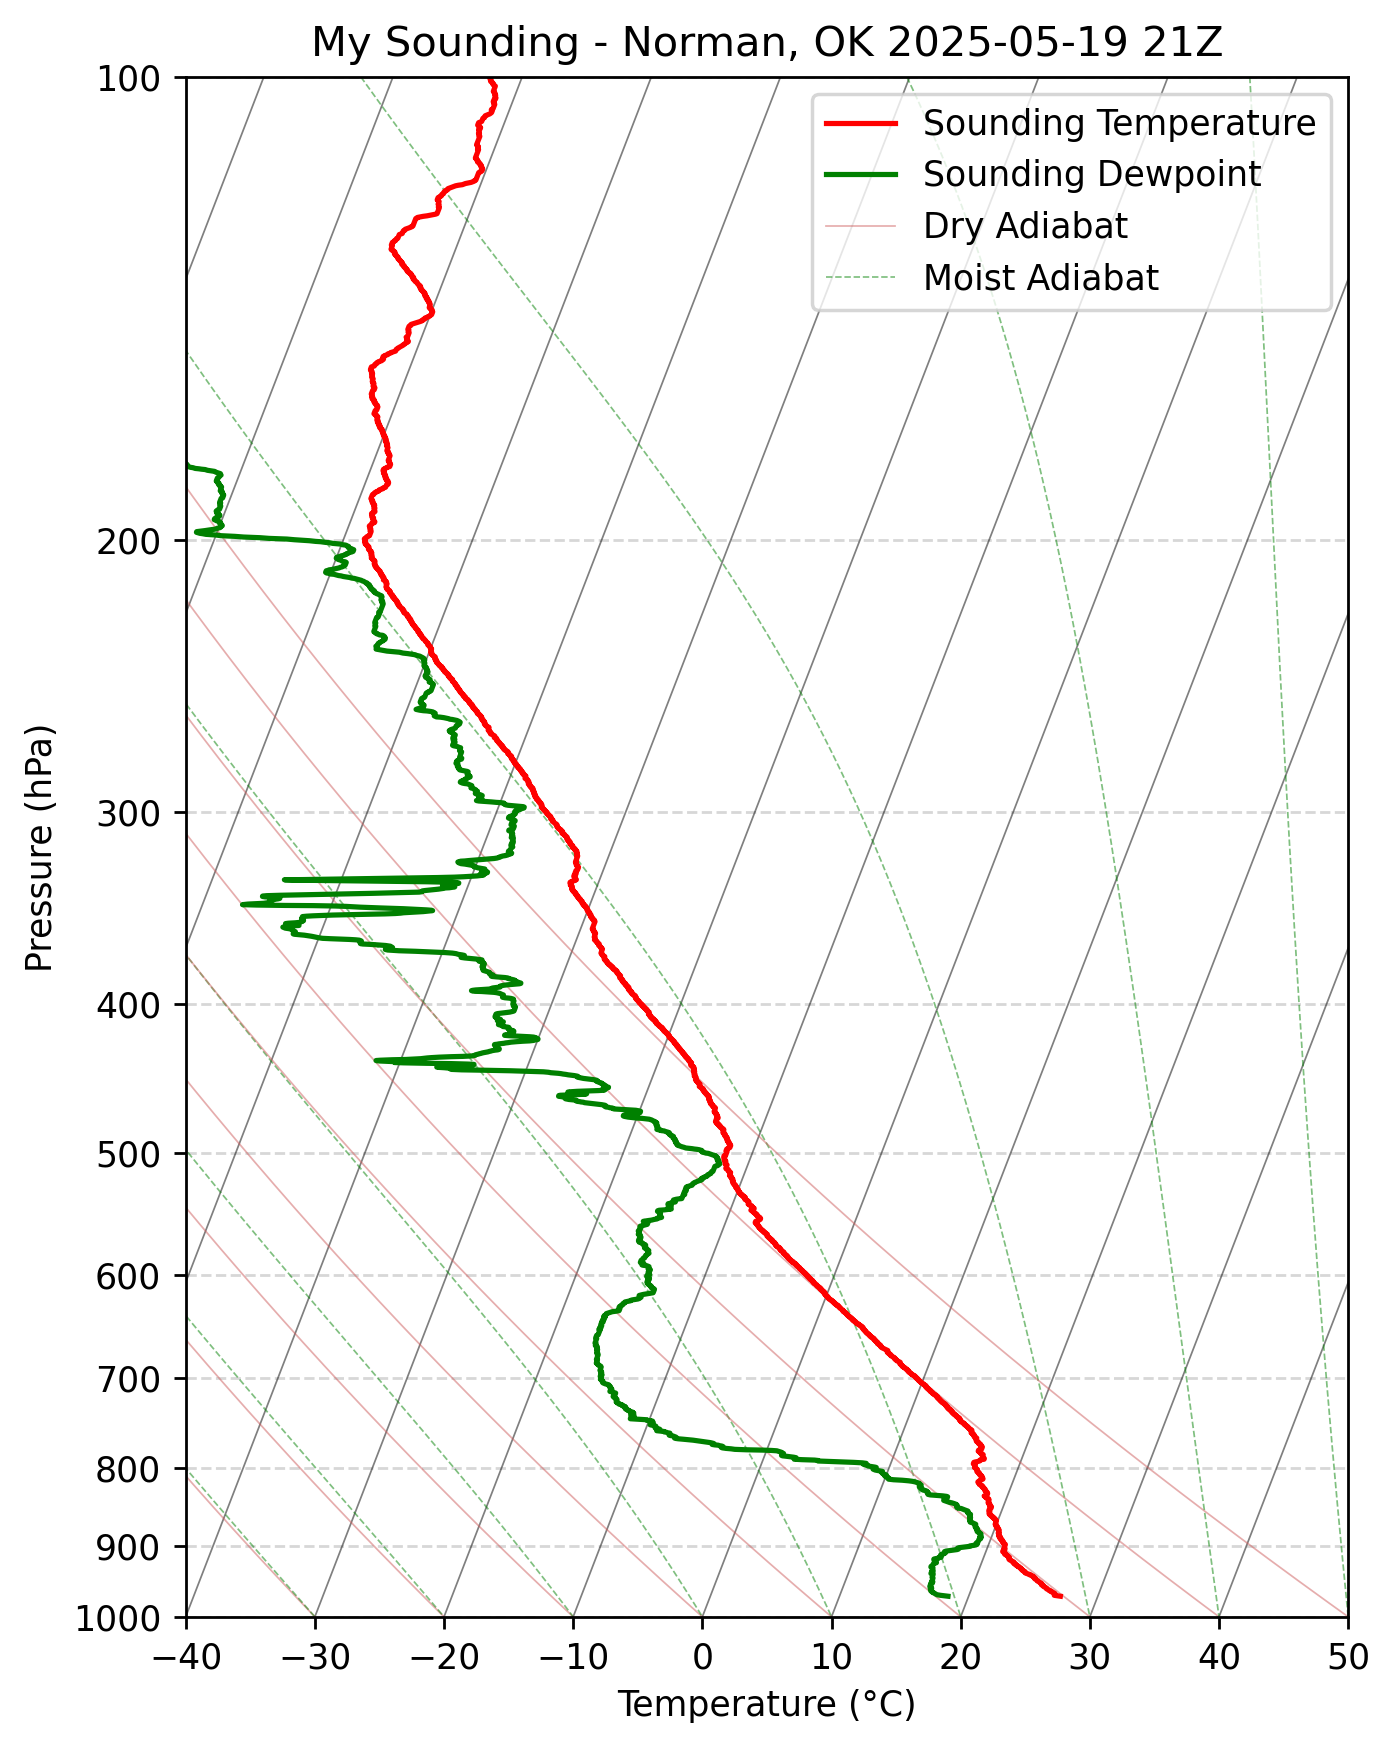

In [41]:

plt.figure(figsize=(6, 8), dpi=250)

for i in range(len(temp_skewed)):#Plot each skew t seperate;u
    plt.plot(temp_skewed[i,:], pres_array, color = "black", linewidth=0.5, alpha = 0.5)

#Calculate and plot moist adiabats
#Get from the dp/dz to vertical z coordinates
for i in range(len(temp_skewed)):
    #I need to calculate density profile, even though I don't have it.\
    #I will need to make an assumption. Assume a dry-adiabatic atmosphere.
    #Poissons equation get temp profile for each dry adaiabat
    temp_profile = ((temp_array[i] + 273.15) * (pres_array / 1000) ** (R_d / C_pd)) - 273.15

    """
    rho = p / (R_d * (temp_profile + 273.15))

    #Actually, I need a way to relate z to P
    dp_dz = -1 * rho * g #Hydrostatic assumpiton

    dp = p[1:] - p[:-1]


    #THis is the vertical z dist between pressure levels.
    dz = - dp / dp_dz[1:]

    #Ugh, this needs to be switched around
    dz = dz[::-1]    

    #Create that sweet sweet z coord.
    z = np.cumsum(dz) 

    dry_adiabat_diff = z * dry_lapse

    #plot the dry adiabats
    dry_adiabat_diff_rev = dry_adiabat_diff[::-1]
    dry_adiabat = temp_array[i] - dry_adiabat_diff_rev
    """#I am so dumb... the temp profiles *are* the adiabats
    # I am leaving this in lol

    #Now, skew this before plotting
    dry_adiabat_skewed = skewT(temp_profile, pres_array[:])

    plt.plot(dry_adiabat_skewed, pres_array[:], color = "indianred", linewidth=0.5, alpha = 0.5)



    #now, plot each moist adiabat
    #First, get the lapse rate for this case:
    moist_adiabat = get_moist_lapse_rate(temp_array[i] , pres_array)[::-1]#Needs to be flipped since I am plotting from low to high p

    """
    one_moist_lapse = moist_lapse_rate[:] * dz[:]
    
    cum_diff_lapse_array = [0]
    #oohhh i see i need to go backward
    for j in range(len(one_moist_lapse) - 1):
        cum_diff_lapse_array.append(one_moist_lapse[j] + cum_diff_lapse_array[j])

    #Now, reverse this array
    cum_diff_lapse_array_rev = cum_diff_lapse_array[::-1]

    #Moist lapse profile is the skewed temp minus the cum_diff_lapse array
    moist_lapse_profile = temp_array[i] - cum_diff_lapse_array_rev
    """
    #Again, dont do this at 2 am.
    # I ws creating the moist adiabat in get_moist_lapse_rate, but not returning it for some reason.
    #Leaving this ehre for fun lol

    moist_lapse_profile_skewed = skewT(moist_adiabat[:-1], pres_array[:-1])

    plt.plot(moist_lapse_profile_skewed, pres_array[:-1], color = "green", linewidth=0.5, alpha = 0.5, linestyle="--")

#Add the observed sounding
sounding_temp_skewed = skewT(sounding_temp, sounding_pres)
sounding_dew_skewed = skewT(sounding_dew, sounding_pres)

plt.plot(sounding_temp_skewed, sounding_pres, color = "red", linewidth=1.5, label = "Sounding Temperature")
plt.plot(sounding_dew_skewed, sounding_pres, color = "green", linewidth=1.5, label = "Sounding Dewpoint")

#I guess I also need to make fake adiabats so I can put them in a legend.
plt.plot([], [], color = "indianred", linewidth=0.5, alpha = 0.5, label = "Dry Adiabat")
plt.plot([], [], color = "green", linewidth=0.5, alpha = 0.5, linestyle="--", label = "Moist Adiabat")

plt.xlim(-40, 50)
plt.grid(axis="y", which="both", linestyle="--", alpha=0.5)
plt.yscale('log')
plt.ylim(1000, 100)
plt.yticks([1000,900,800,700,600,500,400,300,200,100], ["1000","900","800","700","600","500","400","300","200","100"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Pressure (hPa)")
plt.legend(loc="upper right")
plt.title("My Sounding - Norman, OK 2025-05-19 21Z")
plt.show()

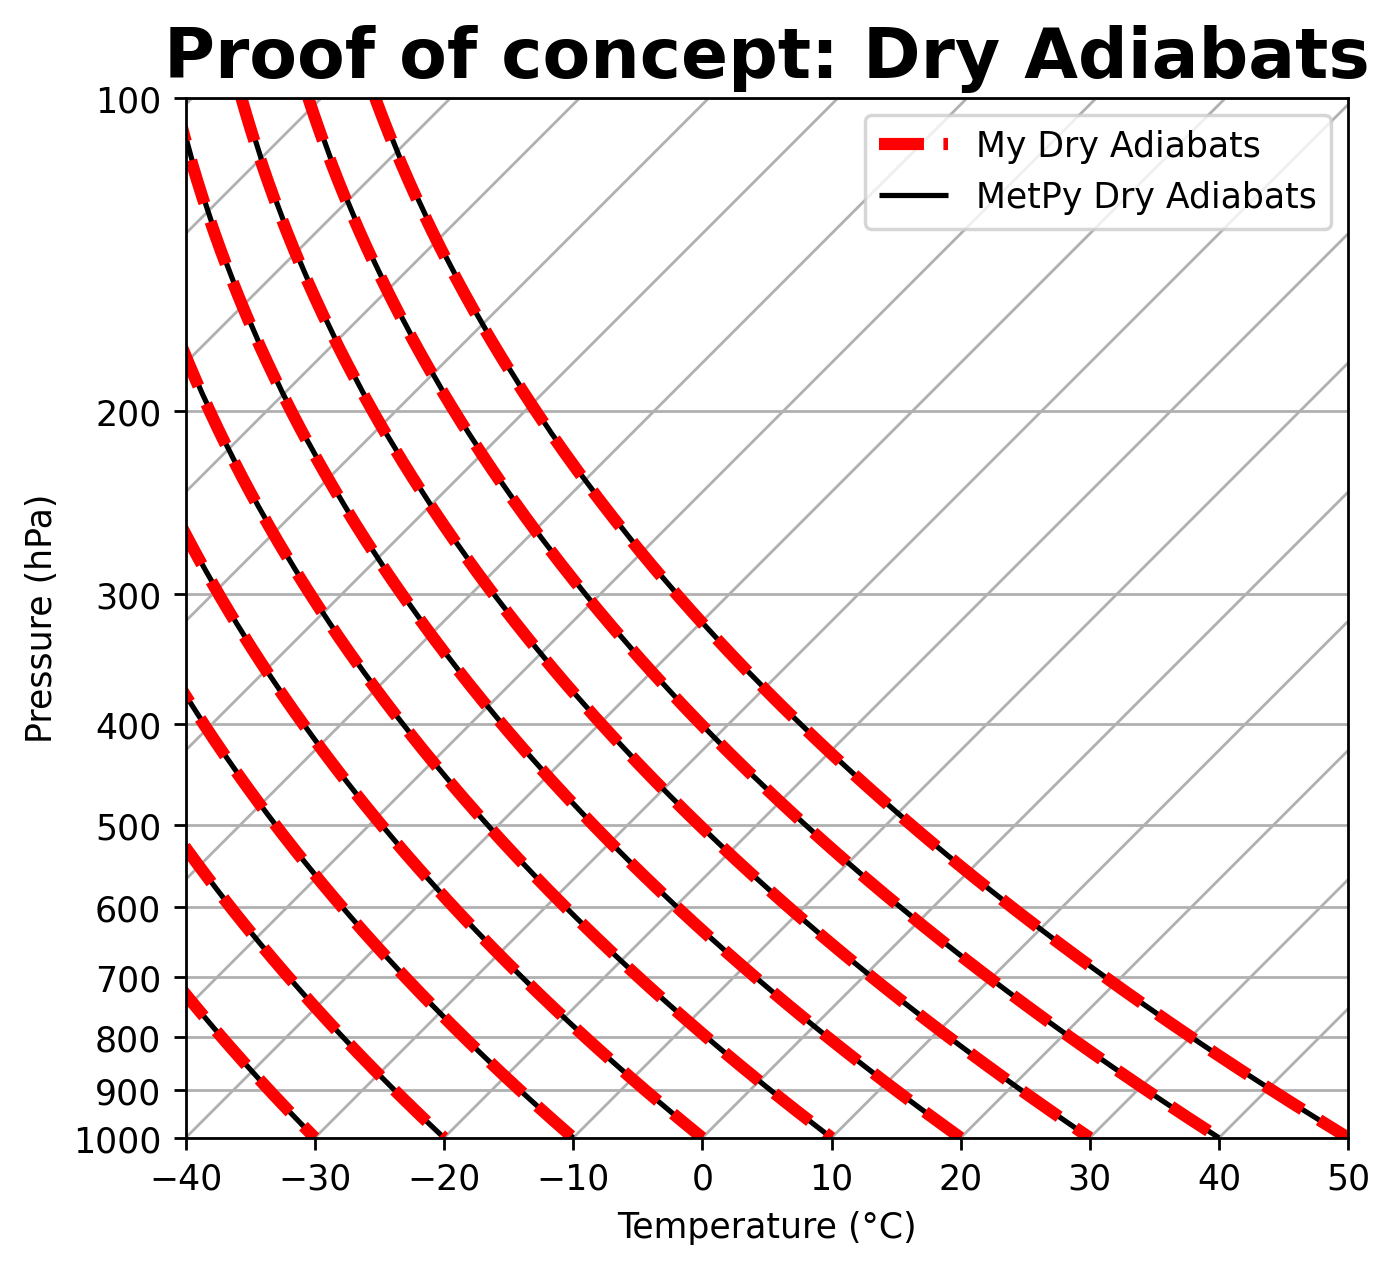

In [40]:
#Now, do the proof of concepts in their own cell:
#Import metpy to do proofs.
from metpy.plots import add_metpy_logo, SkewT, Hodograph
from metpy.units import units

#This code is from a previous skewt code that I made for an assignment
fig = plt.figure(figsize=(6, 8), dpi=250)
skew = SkewT(fig, rotation=45)
#essentially I will plot my adiabats over the actual skewt to see if they match.
# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot
for i in range(len(temp_skewed)):
    #I need to calculate density profile, even though I don't have it.\
    #I will need to make an assumption. Assume a dry-adiabatic atmosphere.
    #Poissons equation get temp profile for each dry adaiabat
    temp_profile = ((temp_array[i] + 273.15) * (pres_array / 1000) ** (R_d / C_pd)) - 273.15

    #Don't need to skew with this package
    #dry_adiabat_skewed = skewT(temp_profile, pres_array[:])

    #plt.plot(dry_adiabat_skewed, pres_array[:], color = "indianred", linewidth=0.5, alpha = 0.5)
    skew.plot(pres_array[:], temp_profile, 'r', linewidth = 3.5, linestyle = '--')

#Make a dummy line for the legend
skew.plot([], [], 'r', linewidth = 3.5, linestyle = '--', label = 'My Dry Adiabats')

#skew.plot(p, Td, 'g')

#Set the axis limits
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 50)

# Add the relevant special lines
skew.plot_dry_adiabats(colors = "black", alpha = 1, linestyles = 'solid', label = 'MetPy Dry Adiabats')
#skew.plot_moist_adiabats()
#skew.plot_mixing_lines()


plt.legend()
plt.title(f'Proof of concept: Dry Adiabats', weight = 'bold', size = 20)
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (hPa)')
plt.show()

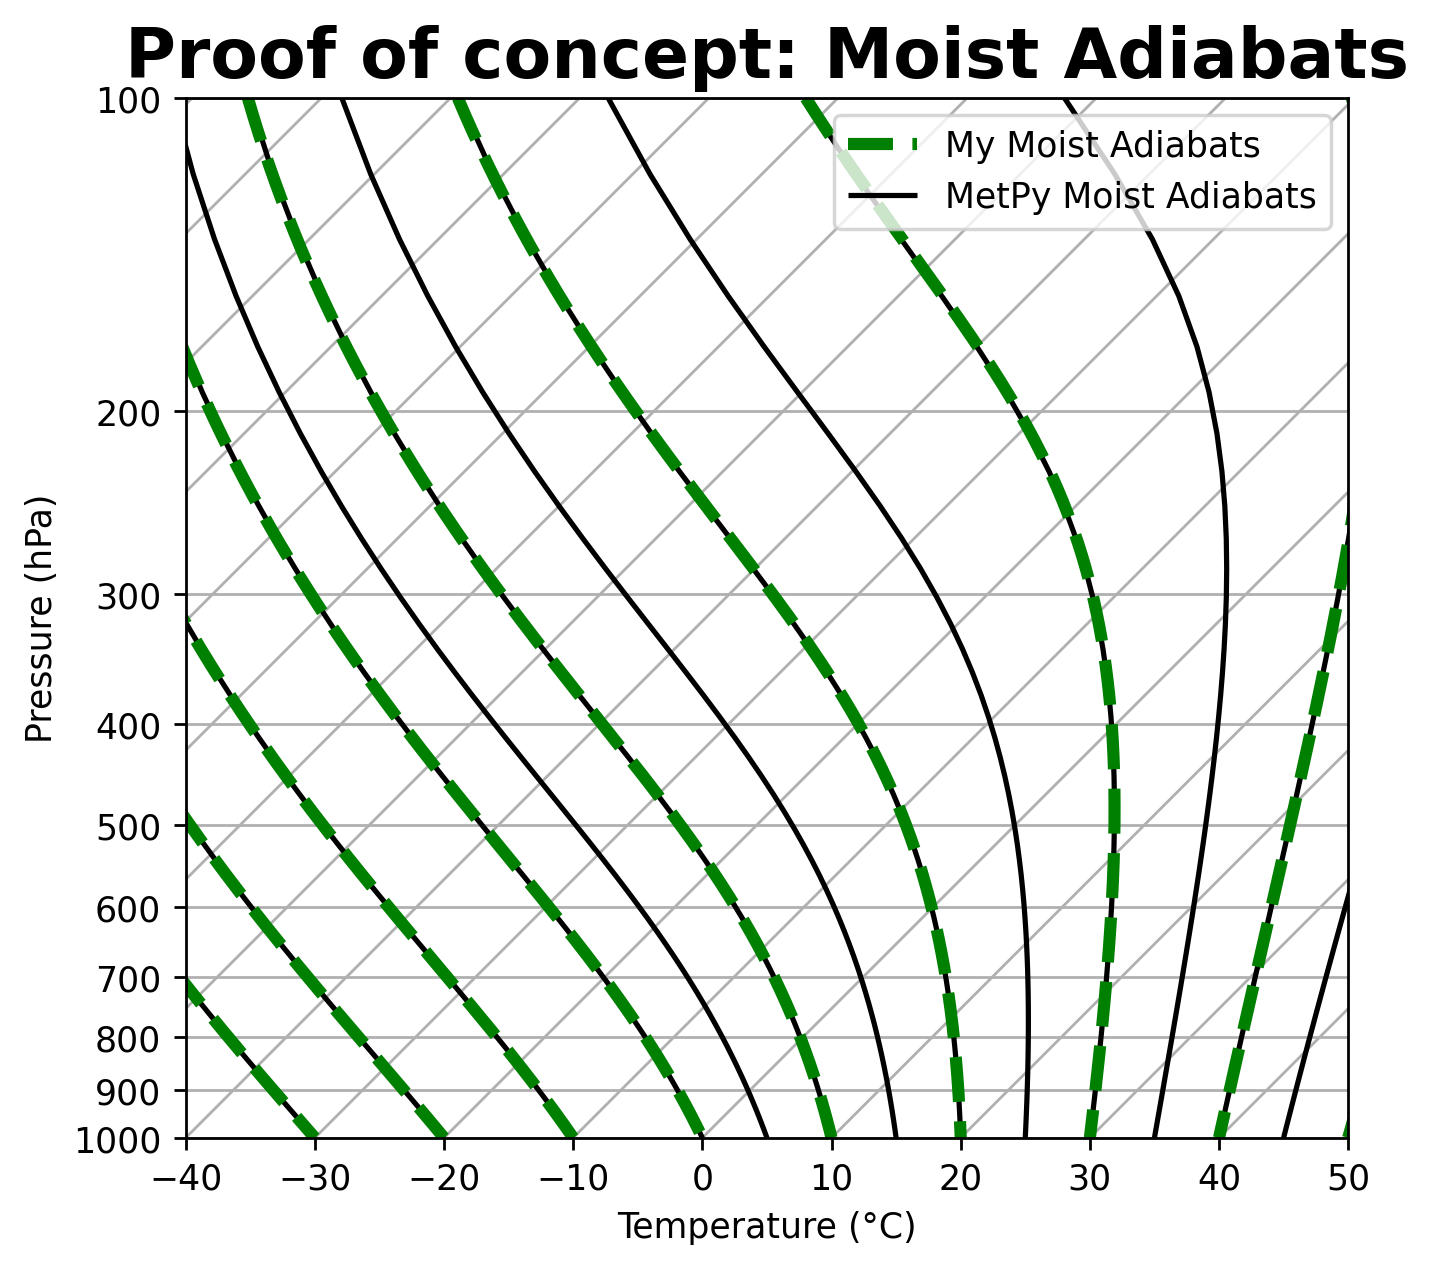

In [38]:
#Again, proof of concept, but with my moist adiabats this time:
#Now, do the proof of concepts in their own cell:
#Import metpy to do proofs.
from metpy.plots import add_metpy_logo, SkewT, Hodograph
from metpy.units import units

#This code is from a previous skewt code that I made for an assignment
fig = plt.figure(figsize=(6, 8), dpi=250)
skew = SkewT(fig, rotation=45)
#essentially I will plot my adiabats over the actual skewt to see if they match.
# Plot the data using normal plotting functions, in this case using
# log scaling in Y, as dictated by the typical meteorological plot
for i in range(len(temp_skewed)):
    #Calc the moist adiabats using my method
    #First, get the lapse rate for this case:
    moist_adiabat = get_moist_lapse_rate(temp_array[i] , pres_array)[::-1]#Needs to be flipped since I am plotting from low to high p
    

    #plt.plot(dry_adiabat_skewed, pres_array[:], color = "indianred", linewidth=0.5, alpha = 0.5)
    skew.plot(pres_array[:], moist_adiabat, 'g', linewidth = 3.5, linestyle = '--')

#plot a dummy line for the legend
skew.plot([], [], 'g', linewidth = 3.5, linestyle = '--', label = 'My Moist Adiabats')
#skew.plot(p, Td, 'g')

#Set the axis limits
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlim(-40, 50)

# Add the relevant special lines
#skew.plot_dry_adiabats(colors = "black", alpha = 1, linestyles = 'solid')
skew.plot_moist_adiabats(colors = "black", alpha = 1, linestyles = 'solid', label = 'MetPy Moist Adiabats')
#skew.plot_mixing_lines()

plt.legend()
plt.title(f'Proof of concept: Moist Adiabats', weight = 'bold', size = 20)
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (hPa)')
plt.show()

# Lab Questions


#### 1) Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel ascends and cools?

The moist lapse rate is lower than the dry lapse rate because latent heat = from condensation is released and heats up the air as it rises. As a parcel rises, the rate of water condensation decreases and decreses, meaning that the latent heat release slows down and the lapse rate increases until it approaches the dry-adiabatic lapse rate. The reason for this slowdown of condensation can by explained by the Clausius-Clapyron (CC) equation. The rate of condensation is proportional to the slope of CC. At warmer temperatures, $e_{s}$ decreases drastically for a unit decrease in temperature, and more water is forced to change phase from vapor to liquid. At cooler temperatures, $e_{s}$ decreases much less for a unit change of temperature. Thus, less water vapor is forced to condense and latent heating slows. 

#### 2) At a fixed pressure, how and why does $\Gamma_{m}$ differ between warmer and colder moist adiabats?

At a fixed pressure, $\Gamma_{m}$ decreases when moving from cooler to warmer temperatures. Again, this results from the increased ability for parcels to hold water as temperature increases, as defined by CC. See answer for 1, as the same reasoning applies here. 